# Comparison of TF-IDF + NMF and Sentence-BERT + BERTopic

This notebook compares the results of the two NLP topic-modelling pipelines. Both pipelines were applied to the same 10,000 consumer complaint narratives. The comparison focuses on the number of topics, topic prevalence, interpretability, specificity, semantic grouping, and limitations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Pipeline 1 results
nmf_assignments = pd.read_csv("/content/nmf_topic_assignments.csv")
nmf_summary = pd.read_csv("/content/nmf_topic_summary.csv")

# Load Pipeline 2 results
bertopic_assignments = pd.read_csv("/content/bertopic_topic_assignments.csv")
bertopic_summary = pd.read_csv("/content/bertopic_topic_summary.csv")

print("NMF assignments:", nmf_assignments.shape)
print("BERTopic assignments:", bertopic_assignments.shape)

print("\nNMF summary:")
display(nmf_summary)

print("\nBERTopic summary:")
display(bertopic_summary)

NMF assignments: (10000, 5)
BERTopic assignments: (10000, 5)

NMF summary:


,topic,count,percentage
0,Banking Customer Service / Funds Issues,2419,24.19
1,Credit Reporting Disputes,1992,19.92
2,Loan & Mortgage Payment Issues,1485,14.85
3,Bank Account Opening / Closure,1211,12.11
4,Debt Collection & Validation,1125,11.25
5,Credit Card & Balance Issues,868,8.68
6,Identity Theft & Fraud,513,5.13
7,Hard Credit Inquiries,387,3.87



BERTopic summary:


,topic,count,percentage
0,Credit Reporting & Account Disputes,5019,50.19
1,"Banking, Loan & Payment Issues",4165,41.65
2,Outliers / Unassigned,567,5.67
3,"Digital Payments, Transactions & Refunds",130,1.30
4,Bank Account Linking Issues,119,1.19


## Pipeline Comparison

The two pipelines were applied to the same 10,000 complaint narratives. TF-IDF + NMF produced eight relatively specific topics, while Sentence-BERT + BERTopic produced four broader semantic topics plus an outlier group. The following comparison examines how the topic structures differ.

In [2]:
# Basic comparison of the two pipelines
comparison_overview = pd.DataFrame({
    "Pipeline": [
        "TF-IDF + NMF",
        "Sentence-BERT + BERTopic"
    ],
    "Vector Representation": [
        "TF-IDF sparse vectors",
        "Sentence-BERT dense embeddings"
    ],
    "Topic Method": [
        "NMF",
        "BERTopic"
    ],
    "Main Topics": [
        8,
        4
    ],
    "Outlier Group": [
        "No",
        "Yes (5.67%)"
    ]
})

display(comparison_overview)

,Pipeline,Vector Representation,Topic Method,Main Topics,Outlier Group
0,TF-IDF + NMF,TF-IDF sparse vectors,NMF,8,No
1,Sentence-BERT + BERTopic,Sentence-BERT dense embeddings,BERTopic,4,Yes (5.67%)


## Relationship Between the Discovered Topics

Because both pipelines used the same complaints in the same order, their topic assignments can be cross-tabulated. This shows how the more detailed NMF topics are grouped within the broader BERTopic semantic clusters.

In [3]:
# Combine topic assignments from both pipelines
comparison_df = pd.DataFrame({
    "NMF Topic": nmf_assignments["nmf_topic_label"],
    "BERTopic Topic": bertopic_assignments["bertopic_topic_label"]
})

# Cross-tabulation of topic assignments
topic_crosstab = pd.crosstab(
    comparison_df["NMF Topic"],
    comparison_df["BERTopic Topic"]
)

print("Topic assignment cross-tabulation:")
display(topic_crosstab)

Topic assignment cross-tabulation:


BERTopic Topic,Bank Account Linking Issues,"Banking, Loan & Payment Issues",Credit Reporting & Account Disputes,"Digital Payments, Transactions & Refunds",Outliers / Unassigned
NMF Topic,,,,,
Bank Account Opening / Closure,88,322,666,21,114
Banking Customer Service / Funds Issues,27,1715,493,84,100
Credit Card & Balance Issues,3,683,140,10,32
Credit Reporting Disputes,1,97,1772,1,121
Debt Collection & Validation,0,50,1024,2,49
Hard Credit Inquiries,0,25,321,2,39
Identity Theft & Fraud,0,16,452,0,45
Loan & Mortgage Payment Issues,0,1257,151,10,67


## Normalized Topic Comparison

The cross-tabulation is normalized by NMF topic so that the percentage of each detailed NMF topic assigned to the broader BERTopic clusters can be examined.

In [4]:
# Convert the cross-tabulation to row percentages
topic_crosstab_pct = pd.crosstab(
    comparison_df["NMF Topic"],
    comparison_df["BERTopic Topic"],
    normalize="index"
) * 100

topic_crosstab_pct = topic_crosstab_pct.round(1)

display(topic_crosstab_pct)

BERTopic Topic,Bank Account Linking Issues,"Banking, Loan & Payment Issues",Credit Reporting & Account Disputes,"Digital Payments, Transactions & Refunds",Outliers / Unassigned
NMF Topic,,,,,
Bank Account Opening / Closure,7.3,26.6,55.0,1.7,9.4
Banking Customer Service / Funds Issues,1.1,70.9,20.4,3.5,4.1
Credit Card & Balance Issues,0.3,78.7,16.1,1.2,3.7
Credit Reporting Disputes,0.1,4.9,89.0,0.1,6.1
Debt Collection & Validation,0.0,4.4,91.0,0.2,4.4
Hard Credit Inquiries,0.0,6.5,82.9,0.5,10.1
Identity Theft & Fraud,0.0,3.1,88.1,0.0,8.8
Loan & Mortgage Payment Issues,0.0,84.6,10.2,0.7,4.5


## Topic Mapping Visualization

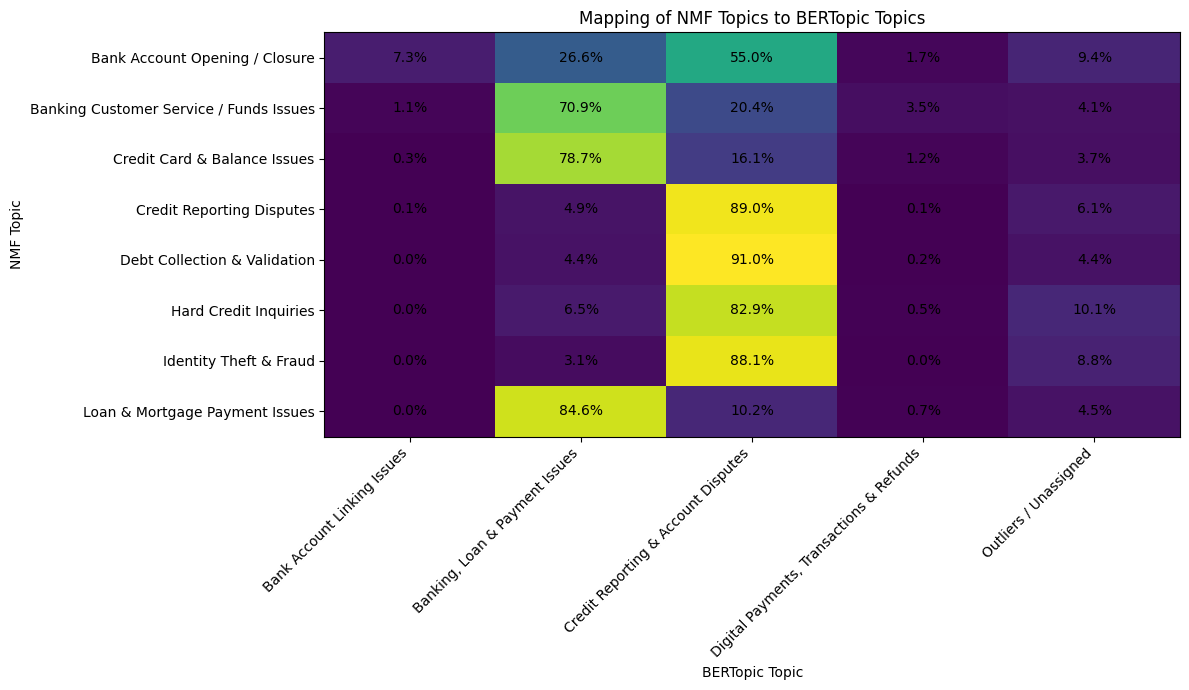

In [5]:
fig, ax = plt.subplots(figsize=(12, 7))

matrix = topic_crosstab_pct.values

im = ax.imshow(matrix, aspect="auto")

ax.set_xticks(range(len(topic_crosstab_pct.columns)))
ax.set_xticklabels(
    topic_crosstab_pct.columns,
    rotation=45,
    ha="right"
)

ax.set_yticks(range(len(topic_crosstab_pct.index)))
ax.set_yticklabels(topic_crosstab_pct.index)

for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        ax.text(
            j,
            i,
            f"{matrix[i, j]:.1f}%",
            ha="center",
            va="center"
        )

ax.set_title("Mapping of NMF Topics to BERTopic Topics")
ax.set_xlabel("BERTopic Topic")
ax.set_ylabel("NMF Topic")

plt.tight_layout()
plt.show()

## Clustering Agreement

In [6]:
from sklearn.metrics import normalized_mutual_info_score

nmi_score = normalized_mutual_info_score(
    nmf_assignments["nmf_topic"],
    bertopic_assignments["bertopic_topic"]
)

print("Normalized Mutual Information:", round(nmi_score, 3))

Normalized Mutual Information: 0.219


## Final Comparison and Conclusion

The two pipelines identified related but structurally different topic patterns from the same 10,000 consumer complaints.

TF-IDF + NMF produced eight relatively specific and interpretable topics. This approach separated issues such as hard credit inquiries, identity theft, debt collection, credit card problems, mortgage payments, and credit reporting disputes. It therefore provides more detailed categories that could be useful for operational analysis and identifying specific areas requiring attention.

Sentence-BERT + BERTopic produced four broader semantic topics and an outlier group. The semantic approach combined several related NMF topics into larger themes. For example, credit reporting disputes, debt collection, identity theft, and hard inquiries were mainly grouped into the broader Credit Reporting & Account Disputes topic.

The normalized mutual information score of 0.219 confirms that the two clustering structures differ substantially. This is expected because the methods represent text differently and use different clustering strategies.

Overall, TF-IDF + NMF provided greater topic specificity and clearer operational categories, while Sentence-BERT + BERTopic captured broader semantic relationships between complaints. For this dataset, NMF is more useful when detailed complaint categories are required, whereas BERTopic is useful for identifying higher-level semantic themes.

In [7]:
# Save the normalized topic mapping
topic_crosstab_pct.to_csv(
    "/content/nmf_bertopic_topic_mapping.csv"
)

# Save the pipeline overview
comparison_overview.to_csv(
    "/content/pipeline_comparison_overview.csv",
    index=False
)

print("Comparison results saved successfully.")

Comparison results saved successfully.
